In [1]:
import os

In [2]:
%pwd

'f:\\Files\\DS&ML\\Flight-Fare-Price-Prediction\\Exp'

In [3]:
os.chdir('../')
%pwd

'f:\\Files\\DS&ML\\Flight-Fare-Price-Prediction'

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv(os.path.join('artifacts', 'data_ingestion', 'flight-fare-data.csv'))
df.head()

,Airline,Source,Source Name,Destination,Destination Name,Departure Date & Time,Arrival Date & Time,Duration (hrs),Stopovers,Aircraft Type,Class,Booking Source,Base Fare (BDT),Tax & Surcharge (BDT),Total Fare (BDT),Seasonality,Days Before Departure
0,Malaysian Airlines,CXB,Cox's Bazar Airport,CCU,Netaji Subhas Chandra Bose International Airpo...,2025-11-17 06:25:00,2025-11-17 07:38:10,1.219526,Direct,Airbus A320,Economy,Online Website,21131.225021,5169.683753,26300.908775,Regular,10
1,Cathay Pacific,BZL,Barisal Airport,CGP,"Shah Amanat International Airport, Chittagong",2025-03-16 00:17:00,2025-03-16 00:53:31,0.608638,Direct,Airbus A320,First Class,Travel Agency,11605.395471,200.000000,11805.395471,Regular,14
2,British Airways,ZYL,"Osmani International Airport, Sylhet",KUL,Kuala Lumpur International Airport,2025-12-13 12:03:00,2025-12-13 14:44:22,2.689651,1 Stop,Boeing 787,Economy,Travel Agency,39882.499349,11982.374902,51864.874251,Winter Holidays,83
3,Singapore Airlines,RJH,"Shah Makhdum Airport, Rajshahi",DAC,"Hazrat Shahjalal International Airport, Dhaka",2025-05-30 03:21:00,2025-05-30 04:02:09,0.686054,Direct,Airbus A320,Economy,Direct Booking,4435.607340,200.000000,4635.607340,Regular,56
4,British Airways,SPD,Saidpur Airport,YYZ,Toronto Pearson International Airport,2025-04-25 09:14:00,2025-04-25 23:17:20,14.055609,1 Stop,Airbus A350,Business,Direct Booking,59243.806146,14886.570922,74130.377068,Regular,90


In [6]:
df.shape

(57000, 17)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57000 entries, 0 to 56999
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Airline                57000 non-null  object 
 1   Source                 57000 non-null  object 
 2   Source Name            57000 non-null  object 
 3   Destination            57000 non-null  object 
 4   Destination Name       57000 non-null  object 
 5   Departure Date & Time  57000 non-null  object 
 6   Arrival Date & Time    57000 non-null  object 
 7   Duration (hrs)         57000 non-null  float64
 8   Stopovers              57000 non-null  object 
 9   Aircraft Type          57000 non-null  object 
 10  Class                  57000 non-null  object 
 11  Booking Source         57000 non-null  object 
 12  Base Fare (BDT)        57000 non-null  float64
 13  Tax & Surcharge (BDT)  57000 non-null  float64
 14  Total Fare (BDT)       57000 non-null  float64
 15  Se

In [8]:
df.describe()

,Duration (hrs),Base Fare (BDT),Tax & Surcharge (BDT),Total Fare (BDT),Days Before Departure
count,57000.000000,57000.000000,57000.000000,57000.000000,57000.000000
mean,3.994955,58899.556573,11448.238494,71030.316199,45.460579
std,4.094043,68840.614499,12124.344329,81769.199536,26.015657
min,0.500000,1600.975688,200.000000,1800.975688,1.000000
25%,1.003745,8856.316983,200.000000,9602.699787,23.000000
50%,2.644656,31615.996792,9450.940481,41307.544990,45.000000
75%,5.490104,85722.930389,17513.046160,103800.906963,68.000000
max,15.831719,449222.933770,73383.440066,558987.332444,90.000000


In [9]:
df.isnull().sum()

Airline                  0
Source                   0
Source Name              0
Destination              0
Destination Name         0
Departure Date & Time    0
Arrival Date & Time      0
Duration (hrs)           0
Stopovers                0
Aircraft Type            0
Class                    0
Booking Source           0
Base Fare (BDT)          0
Tax & Surcharge (BDT)    0
Total Fare (BDT)         0
Seasonality              0
Days Before Departure    0
dtype: int64

In [10]:
df.nunique()

Airline                     24
Source                       8
Source Name                  8
Destination                 20
Destination Name            20
Departure Date & Time    54126
Arrival Date & Time      56944
Duration (hrs)           53135
Stopovers                    3
Aircraft Type                5
Class                        3
Booking Source               3
Base Fare (BDT)          57000
Tax & Surcharge (BDT)    35969
Total Fare (BDT)         57000
Seasonality                  4
Days Before Departure       90
dtype: int64

In [11]:
from sklearn.preprocessing import OrdinalEncoder

names = ['Source Name', 'Destination Name']
not_names = [col for col in df.columns if col not in names]

obj_col = ['Airline', 'Source', 'Destination', 'Aircraft Type', 'Booking Source', 'Seasonality', 'Stopovers', 'Class', 'Departure Date & Time', 'Arrival Date & Time']
ord_ = OrdinalEncoder()
df[obj_col] = ord_.fit_transform(df[obj_col])

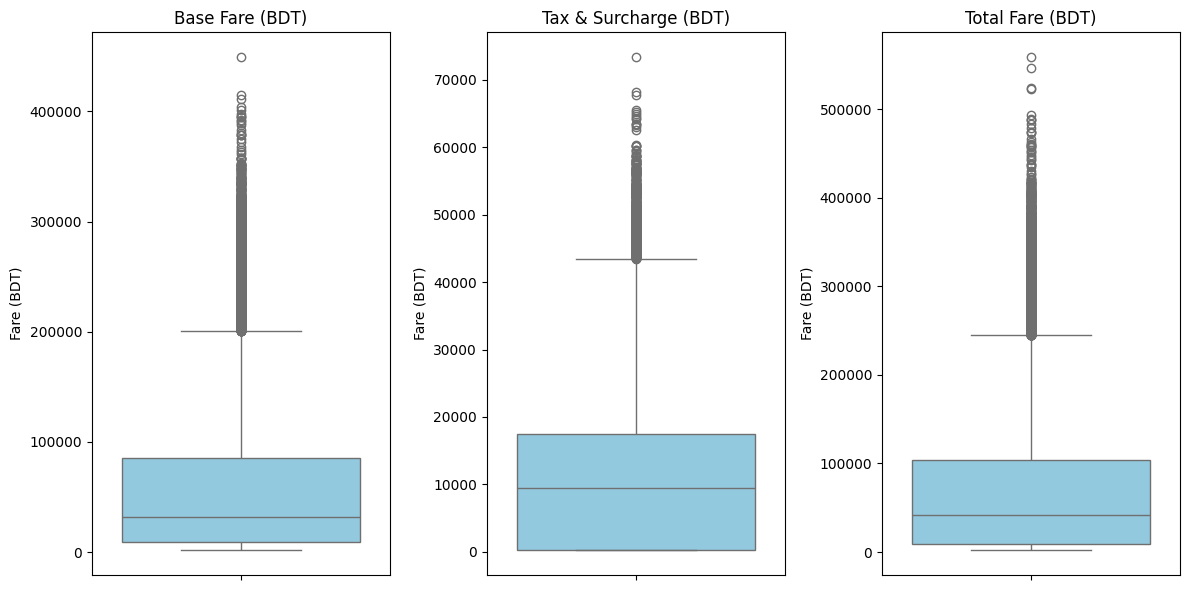

In [12]:
num_col = ['Base Fare (BDT)', 'Tax & Surcharge (BDT)', 'Total Fare (BDT)']

plt.figure(figsize=(12, 6)) 

for i, col in enumerate(num_col, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=df[col], color='skyblue') 
    plt.title(col) 
    plt.ylabel('Fare (BDT)')  

plt.tight_layout() 
plt.show()

## Correlation Heatmap

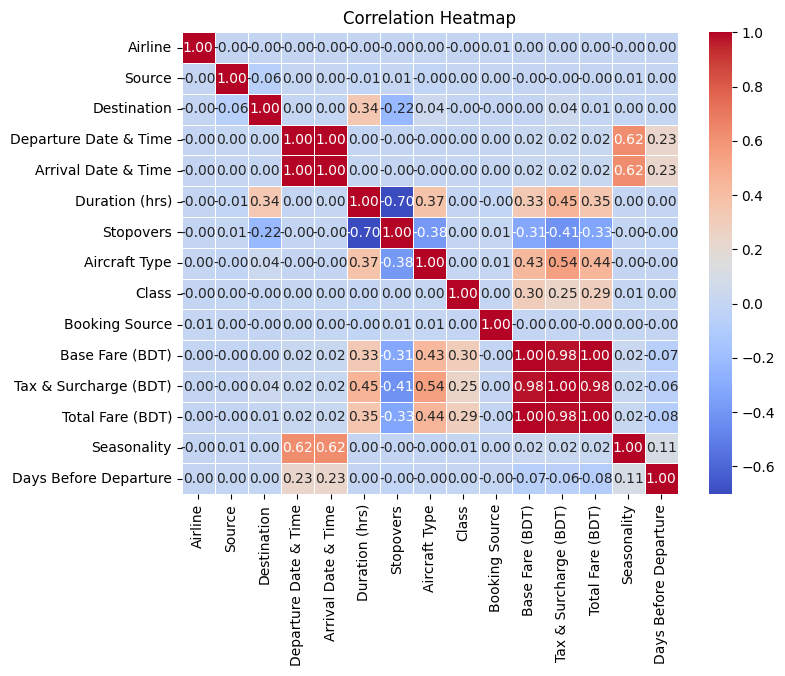

In [13]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[not_names].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title("Correlation Heatmap")

plt.show()

In [14]:
from ydata_profiling import ProfileReport

profile = ProfileReport(df, title='profile')

profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 17/17 [00:01<00:00, 14.78it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]